In [12]:
import sys
sys.path.insert(0, '..')

from utils.preprocessing import load_and_preprocess_data
from utils.evaluation import (
    load_and_evaluate_cnnlstm_model,
)
import joblib
import pandas as pd
from sklearn.metrics import classification_report

In [18]:
df_cicids2017_wednesday = load_and_preprocess_data("../data/CICIDS2017/wednesday_labeled.tsv")
df_cicids2017_friday = load_and_preprocess_data("../data/CICIDS2017/friday_labeled.tsv")
df_ciciot2023 = load_and_preprocess_data("../data/CICIoT2023/ciciot2023_labeled_conn.tsv")

df_cicids2017 = pd.concat([df_cicids2017_wednesday, df_cicids2017_friday], ignore_index=True)

In [19]:
def compute_and_add_time_elapsed(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["id.orig_h", "id.resp_h", "ts"]).reset_index(drop=True)
    df["time_elapsed"] = (
        df.groupby(["id.orig_h", "id.resp_h"])["ts"]
        .diff()
        .fillna(999999.0)
    )
    return df

In [20]:
df = df_ciciot2023.copy()
for col in [
    "ts",
    "duration",
    "orig_bytes",
    "resp_bytes",
    "missed_bytes",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

df = compute_and_add_time_elapsed(df)
duration_safe = df["duration"].replace(0, 1e-6)

df["orig_pkt_rate"] = df["orig_pkts"] / duration_safe
df["orig_byte_rate"] = df["orig_bytes"] / duration_safe
df["pkt_asymmetry"] = df["orig_pkts"] / (df["resp_pkts"] + 1.0)
df["byte_asymmetry"] = df["orig_bytes"] / (df["resp_bytes"] + 1.0)
df["flood_rate"] = df["orig_bytes"] / duration_safe
FEATURES = [
    "proto",
    "service",
    "duration",
    "orig_bytes",
    "resp_bytes",
    "conn_state",
    "missed_bytes",
    "history",
    "orig_pkts",
    "orig_ip_bytes",
    "resp_pkts",
    "resp_ip_bytes",
    "orig_pkt_rate", # New feature
    "orig_byte_rate", # New feature
    "pkt_asymmetry", # New feature
    "byte_asymmetry", # New feature
    "time_elapsed", # New feature
    "flood_rate", # New feature
]

In [21]:
label_column = "label"
X_cicids = df[FEATURES].copy()

df_cicids2017 = df[df["label"].isin(["DOS_HTTP_FLOOD", "PORTSCAN"] + ["BENIGN"])]
y_cicids = df_cicids2017[label_column]

X_ciciot = df_ciciot2023.drop(columns=[label_column])
y_ciciot = df_ciciot2023[label_column]

print("CICIDS test shape:", X_cicids.shape)
print("CICIoT test shape:", X_ciciot.shape)

CICIDS test shape: (2067377, 18)
CICIoT test shape: (2067377, 22)


Evaluation for CICIoT2023-trained CNNLSTM tested on CICIDS2017:

=== CICIoT2023-trained CNNLSTM tested on CICIDS2017 Classification Report ===



c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Rasmus\anaconda3\envs\thesis\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

                precision    recall  f1-score   support

        BENIGN     0.8049    0.9727    0.8809    342255
DOS_HTTP_FLOOD     0.8899    0.9756    0.9308   1508589
      PORTSCAN     0.0000    0.0000    0.0000    216533

      accuracy                         0.8729   2067377
     macro avg     0.5649    0.6494    0.6039   2067377
  weighted avg     0.7826    0.8729    0.8250   2067377


=== Per-Label Accuracy ===

BENIGN: 0.9727
DOS_HTTP_FLOOD: 0.9756
PORTSCAN: 0.0000


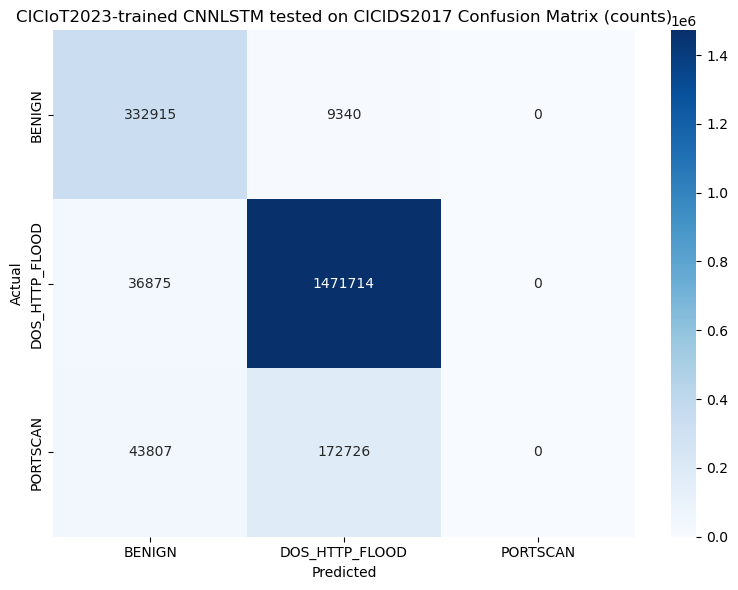

In [22]:
# Load CICIoT2023 model and evaluate on CICIDS2017
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_ciciot2023.joblib",
    X=X_cicids,
    y_true=y_cicids,
    model_name="CICIoT2023-trained CNNLSTM tested on CICIDS2017"
)

Evaluation for CICIDS2017-trained CNNLSTM tested on CICIoT2023:

=== CICIDS2017-trained CNNLSTM tested on CICIoT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.2013    0.9692    0.3334    342255
DOS_HTTP_FLOOD     0.9480    0.1276    0.2250   1508589

      accuracy                         0.2833   1850844
     macro avg     0.5747    0.5484    0.2792   1850844
  weighted avg     0.8099    0.2833    0.2450   1850844


=== Per-Label Accuracy ===

BENIGN: 0.9692
DOS_HTTP_FLOOD: 0.1276


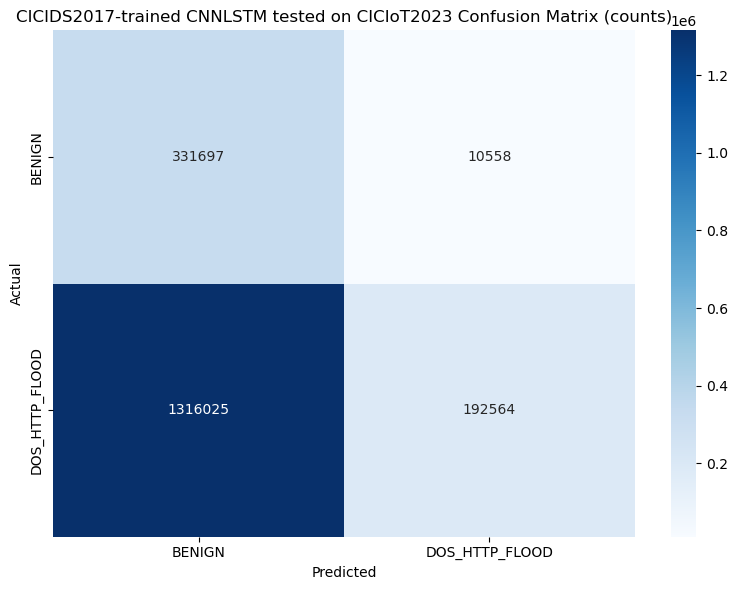

Cross-dataset evaluation saved to: ..\experiments\20260405_210240_2props\cross_eval_on_ciciot2023.json


WindowsPath('../experiments/20260405_210240_2props/cross_eval_on_ciciot2023.json')

In [ ]:
# Load CICIDS2017 model and evaluate on CICIoT2023
load_and_evaluate_cnnlstm_model(
    joblib_path="models/cnnlstm_property_cicids2017.joblib",
    X=X_ciciot,
    y_true=y_ciciot,
    model_name="CICIDS2017-trained CNNLSTM tested on CICIoT2023"
)